# Merging Data Notebook

In [88]:
import pandas as pd
import glob #this is important for loading the data
import os #important for same reason above
import matplotlib.pyplot as plt #simple plotting example
from functools import reduce #simple merging

In [3]:
#Using my own pathway of a folder called data_for_merging, which has all of the csv files in it
folder_path = os.path.expanduser(r"C:\Users\danie\Downloads\data_for_merging\*.csv")

In [15]:
#Loading the datasets into a dictionary of DataFrames
dataframes = {}
df_names = []
for file_path in glob.glob(folder_path):
    file_name = os.path.splitext(os.path.basename(file_path))[0]
    df_names.append(file_name)
    dataframes[file_name] = pd.read_csv(file_path)
    print(f'Loaded: {file_name}')

Loaded: 01 renewable-share-energy
Loaded: 02 modern-renewable-energy-consumption
Loaded: 03 modern-renewable-prod
Loaded: 04 share-electricity-renewables
Loaded: 05 hydropower-consumption
Loaded: 06 hydro-share-energy
Loaded: 07 share-electricity-hydro
Loaded: 08 wind-generation
Loaded: 09 cumulative-installed-wind-energy-capacity-gigawatts
Loaded: 10 wind-share-energy
Loaded: 11 share-electricity-wind
Loaded: 12 solar-energy-consumption
Loaded: 13 installed-solar-PV-capacity
Loaded: 14 solar-share-energy
Loaded: 15 share-electricity-solar
Loaded: 16 biofuel-production
Loaded: 17 installed-geothermal-capacity


In [9]:
#Example of countries we are dealing with
dataframes['01 renewable-share-energy']['Entity'].unique()
#Not all countries are in this dataset?

array(['Africa', 'Africa (BP)', 'Algeria', 'Argentina', 'Asia',
       'Asia Pacific (BP)', 'Australia', 'Austria', 'Azerbaijan',
       'Bangladesh', 'Belarus', 'Belgium', 'Brazil', 'Bulgaria',
       'CIS (BP)', 'Canada', 'Central America (BP)', 'Chile', 'China',
       'Colombia', 'Croatia', 'Cyprus', 'Czechia', 'Denmark',
       'Eastern Africa (BP)', 'Ecuador', 'Egypt', 'Estonia', 'Europe',
       'Europe (BP)', 'European Union (27)', 'Finland', 'France',
       'Germany', 'Greece', 'High-income countries', 'Hong Kong',
       'Hungary', 'Iceland', 'India', 'Indonesia', 'Iran', 'Iraq',
       'Ireland', 'Israel', 'Italy', 'Japan', 'Kazakhstan', 'Kuwait',
       'Latvia', 'Lithuania', 'Lower-middle-income countries',
       'Luxembourg', 'Malaysia', 'Mexico', 'Middle Africa (BP)',
       'Middle East (BP)', 'Morocco', 'Netherlands', 'New Zealand',
       'Non-OECD (BP)', 'North America', 'North America (BP)',
       'North Macedonia', 'Norway', 'OECD (BP)', 'Oceania', 'Oman',
     

In [17]:
#Need an easier way to recall each dataset name
print(df_names)

['01 renewable-share-energy', '02 modern-renewable-energy-consumption', '03 modern-renewable-prod', '04 share-electricity-renewables', '05 hydropower-consumption', '06 hydro-share-energy', '07 share-electricity-hydro', '08 wind-generation', '09 cumulative-installed-wind-energy-capacity-gigawatts', '10 wind-share-energy', '11 share-electricity-wind', '12 solar-energy-consumption', '13 installed-solar-PV-capacity', '14 solar-share-energy', '15 share-electricity-solar', '16 biofuel-production', '17 installed-geothermal-capacity']


In [50]:
#Need to check which datasets don't have countries that are in other datasets
counter = {} #dict to count countries not in key dataset but in other datasets
for main in df_names:
    for other in df_names:
        if main != other:
            for country in dataframes[main]['Entity'].unique():
                val = country in dataframes[other]['Entity'].unique()
                if val == False:
                    print(f"DataFrame {other} does not have {country} from {main}")
                    if country not in counter.setdefault(other,[]):
                        counter[other].append(country)
                    

DataFrame 04 share-electricity-renewables does not have USSR from 01 renewable-share-energy
DataFrame 07 share-electricity-hydro does not have USSR from 01 renewable-share-energy
DataFrame 09 cumulative-installed-wind-energy-capacity-gigawatts does not have Algeria from 01 renewable-share-energy
DataFrame 09 cumulative-installed-wind-energy-capacity-gigawatts does not have Azerbaijan from 01 renewable-share-energy
DataFrame 09 cumulative-installed-wind-energy-capacity-gigawatts does not have Bangladesh from 01 renewable-share-energy
DataFrame 09 cumulative-installed-wind-energy-capacity-gigawatts does not have Belarus from 01 renewable-share-energy
DataFrame 09 cumulative-installed-wind-energy-capacity-gigawatts does not have Central America (BP) from 01 renewable-share-energy
DataFrame 09 cumulative-installed-wind-energy-capacity-gigawatts does not have Colombia from 01 renewable-share-energy
DataFrame 09 cumulative-installed-wind-energy-capacity-gigawatts does not have Croatia from 0

## A lot of countries are missing from some datasets and are present in other datasets

In [52]:
for key in counter: #Looks at each dataset to see which countries they are missing
    print(key)
    print(counter[key])

04 share-electricity-renewables
['USSR', 'Bermuda', 'Gibraltar', 'Niue', 'Saint Helena', 'Asia Pacific', 'CIS', 'Other Europe', 'Other South & Central America', 'South & Central America']
07 share-electricity-hydro
['USSR', 'Bermuda', 'Gibraltar', 'Niue', 'Saint Helena', 'Asia Pacific', 'CIS', 'Other Europe', 'Other South & Central America', 'South & Central America']
09 cumulative-installed-wind-energy-capacity-gigawatts
['Algeria', 'Azerbaijan', 'Bangladesh', 'Belarus', 'Central America (BP)', 'Colombia', 'Croatia', 'Cyprus', 'Czechia', 'Eastern Africa (BP)', 'Ecuador', 'Estonia', 'European Union (27)', 'Hong Kong', 'Hungary', 'Iceland', 'Indonesia', 'Iraq', 'Israel', 'Kazakhstan', 'Kuwait', 'Latvia', 'Lithuania', 'Luxembourg', 'Malaysia', 'Middle Africa (BP)', 'Non-OECD (BP)', 'North Macedonia', 'OECD (BP)', 'Oman', 'Peru', 'Qatar', 'Saudi Arabia', 'Singapore', 'Slovakia', 'Slovenia', 'Sri Lanka', 'Switzerland', 'Trinidad and Tobago', 'Turkmenistan', 'USSR', 'United Arab Emirates', 

In [54]:
for key in counter:
    print(f'{key} has {len(counter[key])} values missing.')
    #Some of these datasets are missing too much, honestly

04 share-electricity-renewables has 10 values missing.
07 share-electricity-hydro has 10 values missing.
09 cumulative-installed-wind-energy-capacity-gigawatts has 194 values missing.
11 share-electricity-wind has 10 values missing.
13 installed-solar-PV-capacity has 192 values missing.
15 share-electricity-solar has 10 values missing.
16 biofuel-production has 221 values missing.
17 installed-geothermal-capacity has 223 values missing.
01 renewable-share-energy has 152 values missing.
02 modern-renewable-energy-consumption has 152 values missing.
06 hydro-share-energy has 152 values missing.
10 wind-share-energy has 152 values missing.
14 solar-share-energy has 152 values missing.
03 modern-renewable-prod has 5 values missing.
05 hydropower-consumption has 5 values missing.
08 wind-generation has 5 values missing.
12 solar-energy-consumption has 5 values missing.


### Datasets with the least missing data are:

In [61]:
indexes = [2,3,4,6,7,10,11,14,] #These indices are the datasets with the least missing countries
for item in indexes:
    print(df_names[item])

03 modern-renewable-prod
04 share-electricity-renewables
05 hydropower-consumption
07 share-electricity-hydro
08 wind-generation
11 share-electricity-wind
12 solar-energy-consumption
15 share-electricity-solar


Given that the datasets with the least missing information are modern renewable production, share of electricity of renewables, hydropower consumption, share of hydro electricity, wind generation, share of windpower electricity, solar energy consumption, and share of solar electricity, these datasets are the most optimal for usage.

In [122]:
dataframes[df_names[11]] # indices 4,7,11 are already in the modern-renewable_prod dataset

,Entity,Code,Year,Electricity from solar (TWh)
0,Afghanistan,AFG,2000,0.00
1,Afghanistan,AFG,2001,0.00
2,Afghanistan,AFG,2002,0.00
3,Afghanistan,AFG,2003,0.00
4,Afghanistan,AFG,2004,0.00
...,...,...,...,...
8678,Zimbabwe,ZWE,2017,0.01
8679,Zimbabwe,ZWE,2018,0.02
8680,Zimbabwe,ZWE,2019,0.03
8681,Zimbabwe,ZWE,2020,0.03


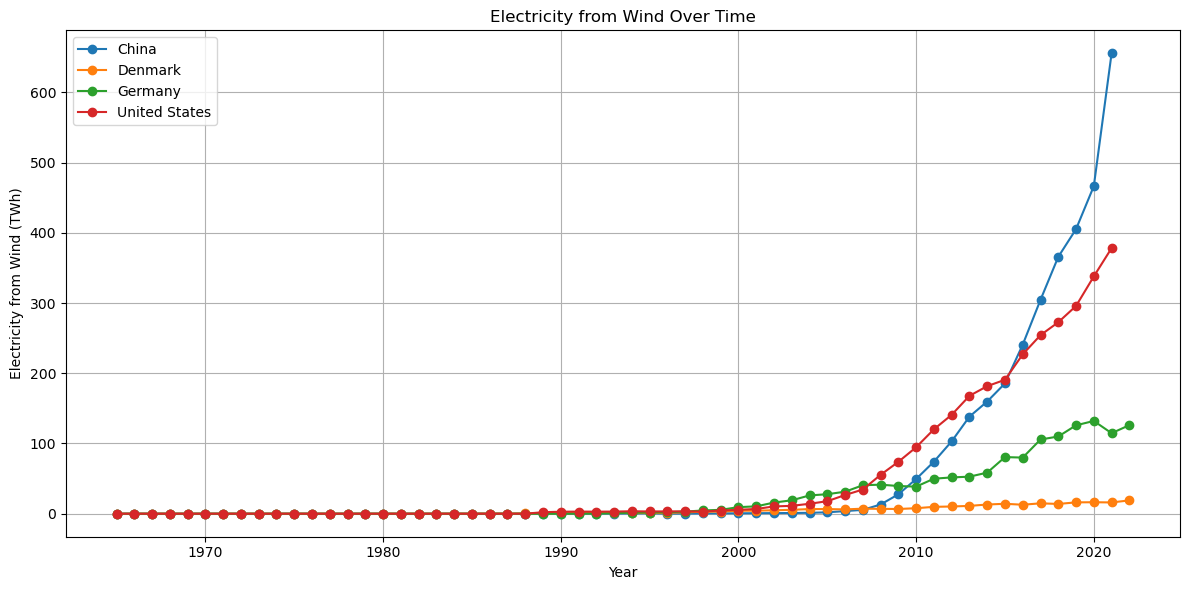

In [70]:
#Example of plotting given a simple dataframe

countries = ["United States", "Germany", "China", "Denmark"]
filtered_df = dataframes[df_names[2]][dataframes[df_names[2]]['Entity'].isin(countries)]

fig, ax = plt.subplots(figsize=(12,6))

for country, group in filtered_df.groupby("Entity"):
    ax.plot(group["Year"], group["Electricity from wind (TWh)"], label=country, marker = "o")

ax.set_title("Electricity from Wind Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Electricity from Wind (TWh)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


In [124]:
print(indexes)
skimindexes = [2,3,6,10,14] #skimming away repeated datasets
print(skimindexes)

[2, 3, 4, 6, 7, 10, 11, 14]
[2, 3, 6, 10, 14]


In [128]:
mergedfs = []#creating merged dataset
for x in skimindexes:
    mergedfs.append(dataframes[df_names[x]])
merged = reduce(lambda left, right: pd.merge(left, right, on= ['Entity', 'Code', 'Year'], how='outer'),mergedfs)

In [130]:
merged

,Entity,Code,Year,Electricity from wind (TWh),Electricity from hydro (TWh),Electricity from solar (TWh),Other renewables including bioenergy (TWh),Renewables (% electricity),Hydro (% electricity),Wind (% electricity),Solar (% electricity)
0,Afghanistan,AFG,2000,0.0,0.31,0.00,0.00,65.957440,65.957440,0.0,0.000000
1,Afghanistan,AFG,2001,0.0,0.50,0.00,0.00,84.745766,84.745766,0.0,0.000000
2,Afghanistan,AFG,2002,0.0,0.56,0.00,0.00,81.159424,81.159424,0.0,0.000000
3,Afghanistan,AFG,2003,0.0,0.63,0.00,0.00,67.021280,67.021280,0.0,0.000000
4,Afghanistan,AFG,2004,0.0,0.56,0.00,0.00,62.921350,62.921350,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
8846,Zimbabwe,ZWE,2017,0.0,3.97,0.01,0.32,58.503407,54.013607,0.0,0.136054
8847,Zimbabwe,ZWE,2018,0.0,5.05,0.02,0.39,59.412407,54.951040,0.0,0.217628
8848,Zimbabwe,ZWE,2019,0.0,4.17,0.03,0.38,55.582527,50.606796,0.0,0.364078
8849,Zimbabwe,ZWE,2020,0.0,3.81,0.03,0.35,55.131580,50.131580,0.0,0.394737


In [132]:
merged.columns #checking for no repeated columns

Index(['Entity', 'Code', 'Year', 'Electricity from wind (TWh)',
       'Electricity from hydro (TWh)', 'Electricity from solar (TWh)',
       'Other renewables including bioenergy (TWh)',
       'Renewables (% electricity)', 'Hydro (% electricity)',
       'Wind (% electricity)', 'Solar (% electricity)'],
      dtype='object')

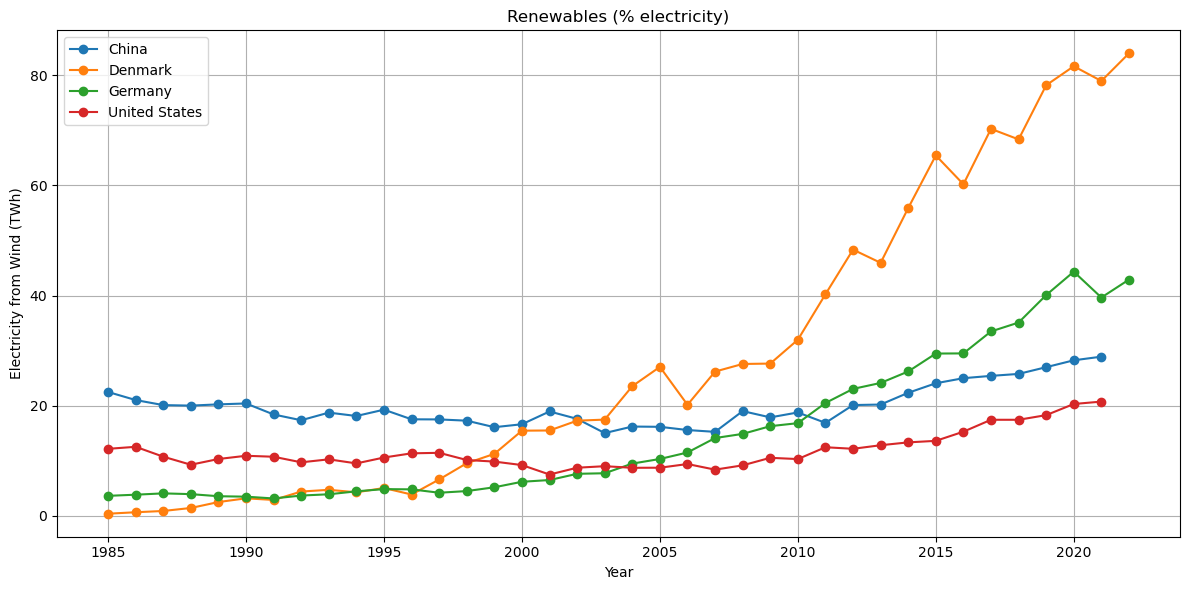

In [116]:
countries = ["United States", "Germany", "China", "Denmark"]
filtered_df = merged[merged['Entity'].isin(countries)]
voi = 'Renewables (% electricity)' #put the variable of interest here
fig, ax = plt.subplots(figsize=(12,6))

for country, group in filtered_df.groupby("Entity"):
    ax.plot(group["Year"], group[voi], label=country, marker = "o")

ax.set_title(voi)
ax.set_xlabel("Year")
ax.set_ylabel("Electricity from Wind (TWh)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

In [138]:
merged.to_csv(r"C:\Users\danie\Downloads\merged_renewables_data.csv", index=False) #this is just turning the dataframe back into a csv for export

In [234]:
lackindex=[0,1,5,8,9,12,13,15,16] #Now onto datasets with missing countries
print(f"Full indices are {indexes}")
print(f"Full indices simplified are {skimindexes}")
print(f"Indices missing countries are {lackindex}")

Full indices are [2, 3, 4, 6, 7, 10, 11, 14]
Full indices simplified are [2, 3, 6, 10, 14]
Indices missing countries are [0, 1, 5, 8, 9, 12, 13, 15, 16]


In [300]:
#creating a test pool of countries that are in the limited information datasets, excluding 16 or 17
testcountries = ['China','Denmark','Africa','Lower-middle-income countries','Upper-middle-income countries','India','France','Mexico', 'Japan','Pakistan','Germany','United States']
num = 0
y= list(dataframes[df_names[num]]['Entity'].unique())
#Looking through data sets to see if I can find countries that are in the missing datasets
#testcountries in y
for i in testcountries:
    print (f'{i} - {i in y}')
#so far these work with all but 15 and 16
dataframes[df_names[num]]['Entity'].unique()
#how about I create a file with all of them merged except for 15 and 16
#I'm using Africa as one simply because there isn't enough data representing countries from
# Africa, and it's difficult to find any specific country in Africa that exists across the datasets

China - True
Denmark - True
Africa - True
Lower-middle-income countries - True
Upper-middle-income countries - True
India - True
France - True
Mexico - True
Japan - True
Pakistan - True
Germany - True
United States - True


array(['Africa', 'Africa (BP)', 'Algeria', 'Argentina', 'Asia',
       'Asia Pacific (BP)', 'Australia', 'Austria', 'Azerbaijan',
       'Bangladesh', 'Belarus', 'Belgium', 'Brazil', 'Bulgaria',
       'CIS (BP)', 'Canada', 'Central America (BP)', 'Chile', 'China',
       'Colombia', 'Croatia', 'Cyprus', 'Czechia', 'Denmark',
       'Eastern Africa (BP)', 'Ecuador', 'Egypt', 'Estonia', 'Europe',
       'Europe (BP)', 'European Union (27)', 'Finland', 'France',
       'Germany', 'Greece', 'High-income countries', 'Hong Kong',
       'Hungary', 'Iceland', 'India', 'Indonesia', 'Iran', 'Iraq',
       'Ireland', 'Israel', 'Italy', 'Japan', 'Kazakhstan', 'Kuwait',
       'Latvia', 'Lithuania', 'Lower-middle-income countries',
       'Luxembourg', 'Malaysia', 'Mexico', 'Middle Africa (BP)',
       'Middle East (BP)', 'Morocco', 'Netherlands', 'New Zealand',
       'Non-OECD (BP)', 'North America', 'North America (BP)',
       'North Macedonia', 'Norway', 'OECD (BP)', 'Oceania', 'Oman',
     

In [354]:
mergedfs2 = []  #Just trying to create the second dataset using only limited information datasets
slackindex=[0,1,5,8,9,12,13]
for x in slackindex:
    mergedfs2.append(dataframes[df_names[x]])
merged2 = reduce(lambda left, right: pd.merge(left, right, on= ['Entity', 'Code', 'Year'], how='outer'),mergedfs2)

In [356]:
merged2_complete = merged2[merged2['Entity'].isin(testcountries)] #taking only the data out that should exist in datasets selected
m2com = merged2_complete #just renaming

In [358]:
m2com

,Entity,Code,Year,Renewables (% equivalent primary energy),Geo Biomass Other - TWh,Solar Generation - TWh,Wind Generation - TWh,Hydro Generation - TWh,Hydro (% equivalent primary energy),Wind Capacity,Wind (% equivalent primary energy),Solar Capacity,Solar (% equivalent primary energy)
0,Africa,NaN,1965,5.747495,NaN,NaN,0.00000,13.905635,5.747495,NaN,0.000000,NaN,NaN
1,Africa,NaN,1966,6.122062,NaN,NaN,0.00000,15.510005,6.122062,NaN,0.000000,NaN,NaN
2,Africa,NaN,1967,6.325731,NaN,NaN,0.00000,16.190636,6.325731,NaN,0.000000,NaN,NaN
3,Africa,NaN,1968,7.005293,NaN,NaN,0.00000,18.938341,7.005293,NaN,0.000000,NaN,NaN
4,Africa,NaN,1969,7.956088,NaN,NaN,0.00000,22.100891,7.956088,NaN,0.000000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5442,Upper-middle-income countries,NaN,2017,11.880961,166.11080,137.13666,393.85367,2016.754800,8.732356,194.65816,1.705349,145.83273,0.593789
5443,Upper-middle-income countries,NaN,2018,12.425097,187.72731,208.11162,466.95074,2085.247800,8.684197,219.80740,1.944658,196.80761,0.866699
5444,Upper-middle-income countries,NaN,2019,13.105095,211.42967,267.28980,526.37823,2185.356200,8.862996,248.49834,2.134795,233.24031,1.084028
5445,Upper-middle-income countries,NaN,2020,13.998779,240.18889,316.23578,601.05023,2230.803500,9.088311,326.86666,2.448683,289.18834,1.288347


In [320]:
m2com['Entity'].unique()

array(['Africa', 'China', 'Denmark', 'France', 'Germany', 'India',
       'Japan', 'Lower-middle-income countries', 'Mexico', 'Pakistan',
       'United States', 'Upper-middle-income countries'], dtype=object)

In [360]:
m2com = m2com.drop(columns=['Code'])

In [362]:
m2com

,Entity,Year,Renewables (% equivalent primary energy),Geo Biomass Other - TWh,Solar Generation - TWh,Wind Generation - TWh,Hydro Generation - TWh,Hydro (% equivalent primary energy),Wind Capacity,Wind (% equivalent primary energy),Solar Capacity,Solar (% equivalent primary energy)
0,Africa,1965,5.747495,NaN,NaN,0.00000,13.905635,5.747495,NaN,0.000000,NaN,NaN
1,Africa,1966,6.122062,NaN,NaN,0.00000,15.510005,6.122062,NaN,0.000000,NaN,NaN
2,Africa,1967,6.325731,NaN,NaN,0.00000,16.190636,6.325731,NaN,0.000000,NaN,NaN
3,Africa,1968,7.005293,NaN,NaN,0.00000,18.938341,7.005293,NaN,0.000000,NaN,NaN
4,Africa,1969,7.956088,NaN,NaN,0.00000,22.100891,7.956088,NaN,0.000000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
5442,Upper-middle-income countries,2017,11.880961,166.11080,137.13666,393.85367,2016.754800,8.732356,194.65816,1.705349,145.83273,0.593789
5443,Upper-middle-income countries,2018,12.425097,187.72731,208.11162,466.95074,2085.247800,8.684197,219.80740,1.944658,196.80761,0.866699
5444,Upper-middle-income countries,2019,13.105095,211.42967,267.28980,526.37823,2185.356200,8.862996,248.49834,2.134795,233.24031,1.084028
5445,Upper-middle-income countries,2020,13.998779,240.18889,316.23578,601.05023,2230.803500,9.088311,326.86666,2.448683,289.18834,1.288347


In [364]:
m2com.to_csv(r"C:\Users\danie\Downloads\merged_capacity_data.csv", index=False) #this is just turning the dataframe back into a csv for export

In [406]:
testcountries1 = ['China','France','Mexico','Germany','Italy','United States'] #Now selecting countries that are in all datasets
#these are the countries that are in all data
for num in range(0,17):#lackindex:
    for i in testcountries1:
        #print (f'{i} - {i in list(dataframes[df_names[num]]['Entity'].unique())}')
        if (i in list(dataframes[df_names[num]]['Entity'].unique())) == False:
            print(f"{i} is not in {df_names[num]}")


In [434]:
listn=[0, 1, 2, 3, 5, 6, 8, 9, 10, 12, 13, 14, 15, 16]

In [436]:
mergedfs3 = [] #same as last time
for x in listn:
    mergedfs3.append(dataframes[df_names[x]])
merged3 = reduce(lambda left, right: pd.merge(left, right, on= ['Entity', 'Code', 'Year'], how='outer'),mergedfs3)

In [438]:
merged3

,Entity,Code,Year,Renewables (% equivalent primary energy),Geo Biomass Other - TWh,Solar Generation - TWh,Wind Generation - TWh,Hydro Generation - TWh,Electricity from wind (TWh),Electricity from hydro (TWh),...,Hydro (% equivalent primary energy),Hydro (% electricity),Wind Capacity,Wind (% equivalent primary energy),Wind (% electricity),Solar Capacity,Solar (% equivalent primary energy),Solar (% electricity),Biofuels Production - TWh - Total,Geothermal Capacity
0,Afghanistan,AFG,2000,NaN,NaN,NaN,NaN,NaN,0.0,0.31,...,NaN,65.957440,NaN,NaN,0.0,NaN,NaN,0.000000,NaN,NaN
1,Afghanistan,AFG,2001,NaN,NaN,NaN,NaN,NaN,0.0,0.50,...,NaN,84.745766,NaN,NaN,0.0,NaN,NaN,0.000000,NaN,NaN
2,Afghanistan,AFG,2002,NaN,NaN,NaN,NaN,NaN,0.0,0.56,...,NaN,81.159424,NaN,NaN,0.0,NaN,NaN,0.000000,NaN,NaN
3,Afghanistan,AFG,2003,NaN,NaN,NaN,NaN,NaN,0.0,0.63,...,NaN,67.021280,NaN,NaN,0.0,NaN,NaN,0.000000,NaN,NaN
4,Afghanistan,AFG,2004,NaN,NaN,NaN,NaN,NaN,0.0,0.56,...,NaN,62.921350,NaN,NaN,0.0,NaN,NaN,0.000000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8992,Zimbabwe,ZWE,2017,NaN,NaN,NaN,NaN,NaN,0.0,3.97,...,NaN,54.013607,NaN,NaN,0.0,NaN,NaN,0.136054,NaN,NaN
8993,Zimbabwe,ZWE,2018,NaN,NaN,NaN,NaN,NaN,0.0,5.05,...,NaN,54.951040,NaN,NaN,0.0,NaN,NaN,0.217628,NaN,NaN
8994,Zimbabwe,ZWE,2019,NaN,NaN,NaN,NaN,NaN,0.0,4.17,...,NaN,50.606796,NaN,NaN,0.0,NaN,NaN,0.364078,NaN,NaN
8995,Zimbabwe,ZWE,2020,NaN,NaN,NaN,NaN,NaN,0.0,3.81,...,NaN,50.131580,NaN,NaN,0.0,NaN,NaN,0.394737,NaN,NaN


In [440]:
merged3_complete = merged3[merged3['Entity'].isin(testcountries1)] #limiting combined dataframe to countries specified
m3com = merged3_complete

In [442]:
m3com.reset_index
m3com

,Entity,Code,Year,Renewables (% equivalent primary energy),Geo Biomass Other - TWh,Solar Generation - TWh,Wind Generation - TWh,Hydro Generation - TWh,Electricity from wind (TWh),Electricity from hydro (TWh),...,Hydro (% equivalent primary energy),Hydro (% electricity),Wind Capacity,Wind (% equivalent primary energy),Wind (% electricity),Solar Capacity,Solar (% equivalent primary energy),Solar (% electricity),Biofuels Production - TWh - Total,Geothermal Capacity
1674,China,CHN,1965,4.253407,0.000000,0.00000,0.00000,22.097000,0.00,22.097000,...,4.253407,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN
1675,China,CHN,1966,3.983123,0.000000,0.00000,0.00000,22.485907,0.00,22.485907,...,3.983123,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN
1676,China,CHN,1967,3.818398,0.000000,0.00000,0.00000,19.383488,0.00,19.383488,...,3.818398,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN
1677,China,CHN,1968,4.458871,0.000000,0.00000,0.00000,22.870396,0.00,22.870396,...,4.458871,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN
1678,China,CHN,1969,3.727402,0.000000,0.00000,0.00000,23.259302,0.00,23.259302,...,3.727402,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8513,United States,USA,2017,9.082049,82.800320,78.05758,256.87140,296.806460,254.30,293.840000,...,3.059325,7.251173,87.5970,2.647696,6.275433,41.357000,0.804577,1.907060,411.91720,2483.0
8514,United States,USA,2018,8.964939,81.893200,94.30808,275.42166,289.514600,272.67,286.620000,...,2.862129,6.821768,94.5160,2.722808,6.489749,49.812000,0.932326,2.222037,424.44006,2540.5
8515,United States,USA,2019,9.315263,76.820540,107.97374,298.87120,285.467650,295.88,282.610000,...,2.831907,6.796156,104.0522,2.964874,7.115271,59.068000,1.071125,2.570472,412.82147,2555.3
8516,United States,USA,2020,10.532232,74.307320,132.04141,341.35156,282.780500,337.94,279.950000,...,3.019789,6.924006,118.7317,3.645264,8.358273,73.813700,1.410059,3.233099,374.58826,2587.0


In [446]:
m3com.to_csv(r"C:\Users\danie\Downloads\six_country_merged_data.csv", index=False) #All data merged for few countries shared among datasets